<a href="https://colab.research.google.com/github/sumnima2468/CSMC/blob/main/CSMC_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('/content/sample_data/marketing_campaign-selected-columns.csv')

print(df)

         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumStorePurchases  \
0            0  04-09-2012       58       635  ...            

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,4,7,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,5,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,10,4,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,4,6,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,6,5,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df['Income'].describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


copy of original

Income

In [6]:
df_copy_income=df.copy()

In [7]:
df_copy_income=df_copy_income.dropna(subset=["Income"])

In [8]:
df_copy_income.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

feature engineering

In [9]:
# Convert date
#df_copy_income["Dt_Customer"] = pd.to_datetime(
    #df_copy_income["Dt_Customer"]
#)

# Age
df_copy_income["Age"] = (
    2026 - df_copy_income["Year_Birth"]
)

# Customer Tenure
#latest_date = df_copy_income["Dt_Customer"].max()

#df_copy_income["Customer_Tenure"] = (
   # latest_date - df_copy_income["Dt_Customer"]
#).dt.days

# Family Size
df_copy_income["Family_Size"] = (
    df_copy_income["Kidhome"] +
    df_copy_income["Teenhome"] +
    1
)

# Total Spending
df_copy_income["Total_Spending"] = (
    df_copy_income["MntWines"] +
    df_copy_income["MntFruits"] +
    df_copy_income["MntMeatProducts"] +
    df_copy_income["MntFishProducts"] +
    df_copy_income["MntSweetProducts"] +
    df_copy_income["MntGoldProds"]
)

# Total Purchases
df_copy_income["Total_Purchases"] = (
    df_copy_income["NumWebPurchases"] +
    df_copy_income["NumCatalogPurchases"] +
    df_copy_income["NumStorePurchases"]
)

# Campaign Acceptance
df_copy_income["Campaign_Acceptance"] = (
    df_copy_income["AcceptedCmp1"] +
    df_copy_income["AcceptedCmp2"] +
    df_copy_income["AcceptedCmp3"] +
    df_copy_income["AcceptedCmp4"] +
    df_copy_income["Response"]
)

In [10]:
# Convert Dt_Customer to date format
df_copy_income["Dt_Customer"] = pd.to_datetime(
    df_copy_income["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)


In [11]:
a=(df_copy_income['Age']>100).sum()
print(a)

df_copy_income=df_copy_income.drop(df_copy_income[df_copy_income['Age']>100].index)

df_copy_income.info()

3
<class 'pandas.core.frame.DataFrame'>
Index: 2213 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2213 non-null   int64         
 1   Year_Birth           2213 non-null   int64         
 2   Education            2213 non-null   object        
 3   Marital_Status       2213 non-null   object        
 4   Income               2213 non-null   float64       
 5   Kidhome              2213 non-null   int64         
 6   Teenhome             2213 non-null   int64         
 7   Dt_Customer          2213 non-null   datetime64[ns]
 8   Recency              2213 non-null   int64         
 9   MntWines             2213 non-null   int64         
 10  MntFruits            2213 non-null   int64         
 11  MntMeatProducts      2213 non-null   int64         
 12  MntFishProducts      2213 non-null   int64         
 13  MntSweetProducts     2213 non-null  

In [12]:
df_copy_income["Dt_Customer"].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


In [13]:
df_copy_income["Dt_Customer"].isnull().sum()

np.int64(0)

In [14]:
# Customer Tenure
latest_date = df_copy_income["Dt_Customer"].max()
df_copy_income["Customer_Tenure"] = (
   latest_date - df_copy_income["Dt_Customer"]
).dt.days


In [15]:
df_copy_income.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Family_Size,Total_Spending,Total_Purchases,Campaign_Acceptance,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,1,1617,22,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,3,27,4,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,1,776,20,0,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,2,53,6,0,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,2,422,14,0,161


In [16]:
cluster_features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure",
    "Family_Size",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Campaign_Acceptance"
]

df_cluster = df_copy_income[cluster_features].copy()

df_cluster.info()

df_cluster.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 2213 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2213 non-null   int64  
 1   Income               2213 non-null   float64
 2   Recency              2213 non-null   int64  
 3   Customer_Tenure      2213 non-null   int64  
 4   Family_Size          2213 non-null   int64  
 5   Total_Spending       2213 non-null   int64  
 6   Total_Purchases      2213 non-null   int64  
 7   NumDealsPurchases    2213 non-null   int64  
 8   NumWebVisitsMonth    2213 non-null   int64  
 9   Campaign_Acceptance  2213 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 190.2 KB


,0
Age,0
Income,0
Recency,0
Customer_Tenure,0
Family_Size,0
Total_Spending,0
Total_Purchases,0
NumDealsPurchases,0
NumWebVisitsMonth,0
Campaign_Acceptance,0


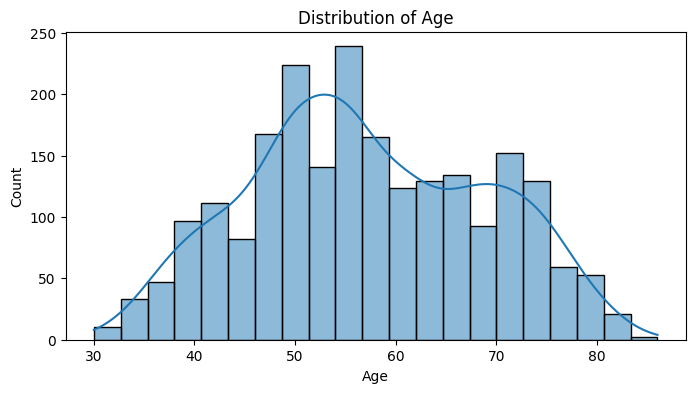

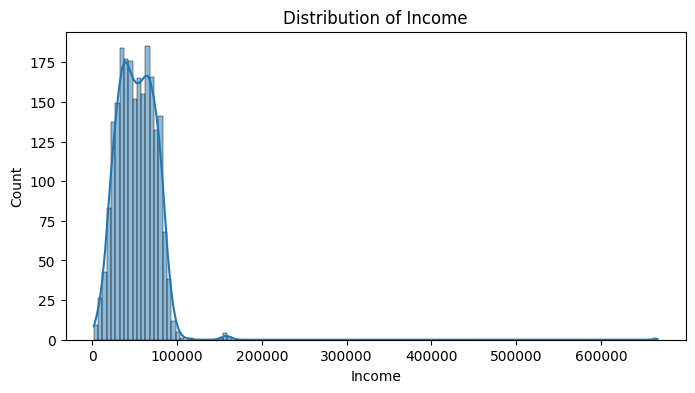

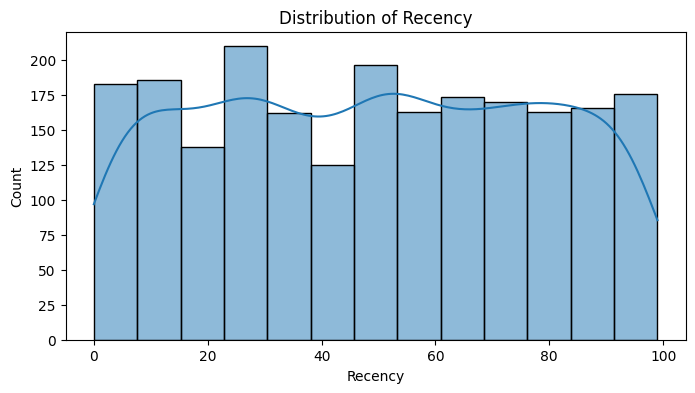

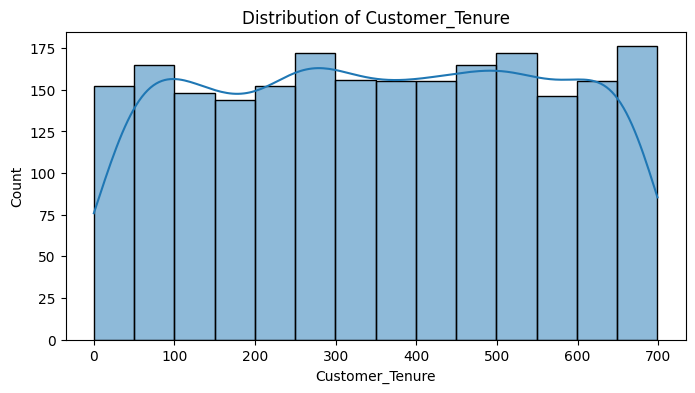

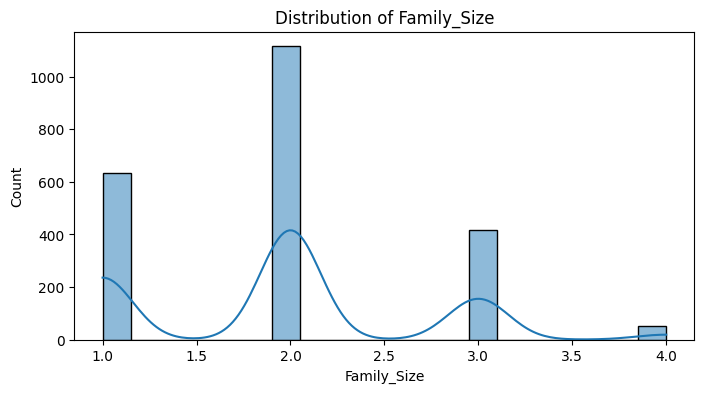

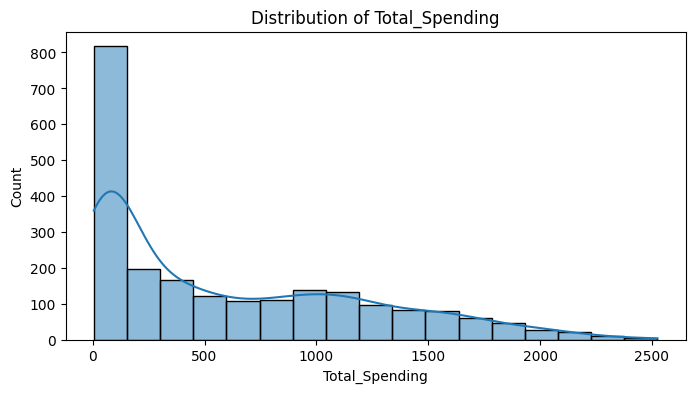

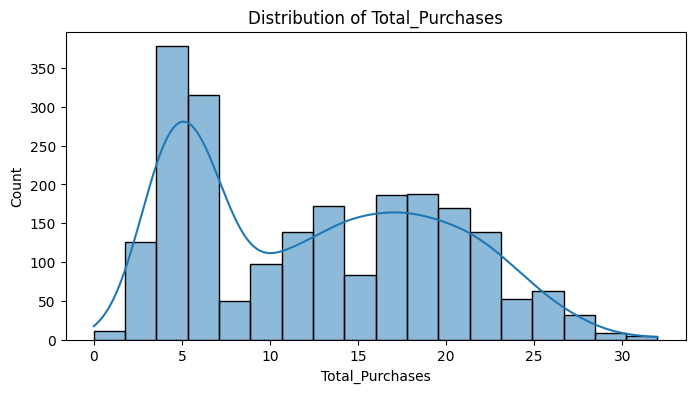

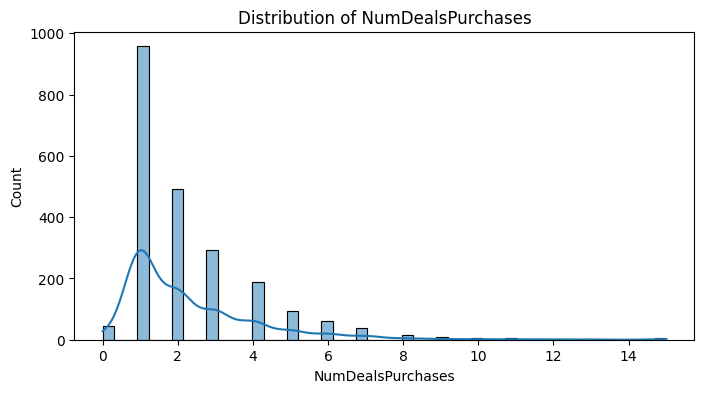

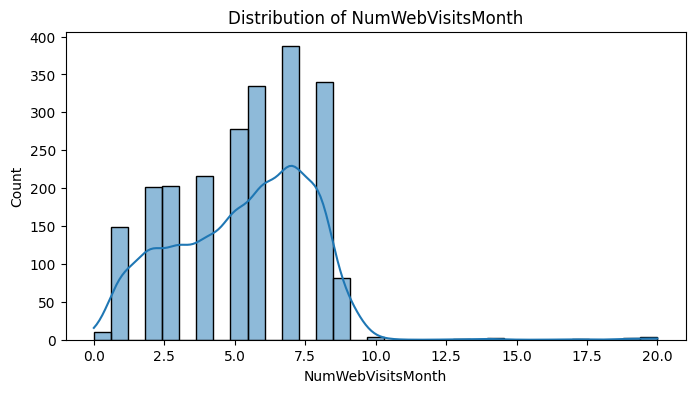

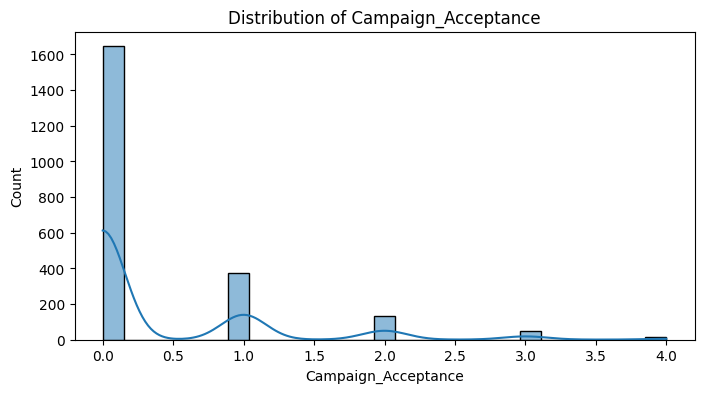

In [17]:
for col in df_cluster.columns:
    plt.figure(figsize=(8,4))
    sb.histplot(df_cluster[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

age vs total spending

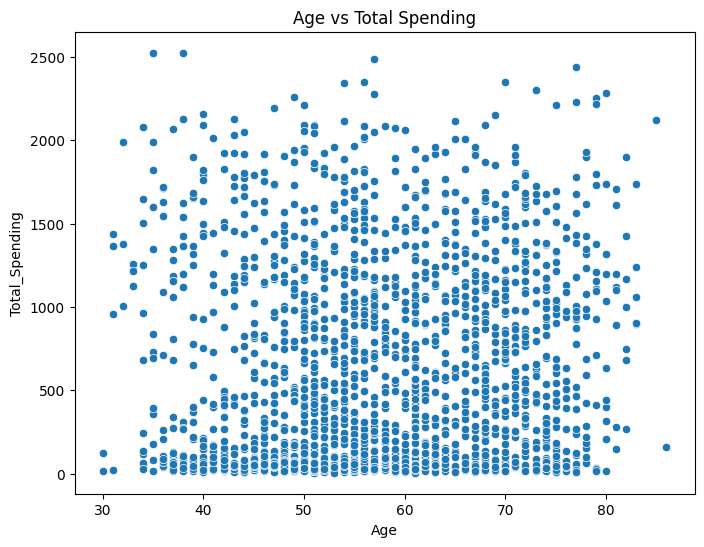

In [18]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    data=df_cluster,
    x='Age',
    y='Total_Spending'
)

plt.title("Age vs Total Spending")
plt.show()

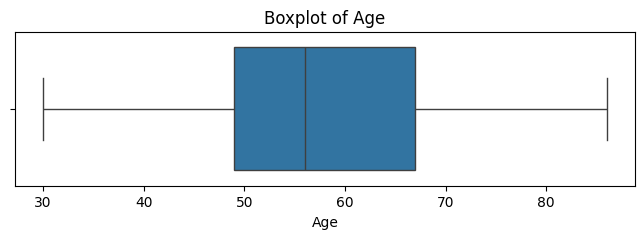

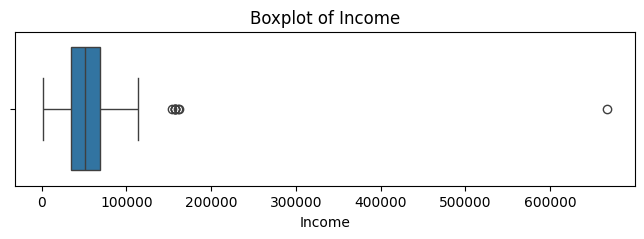

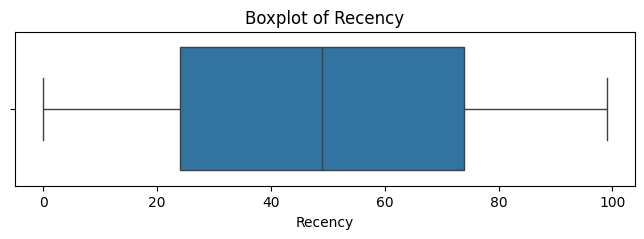

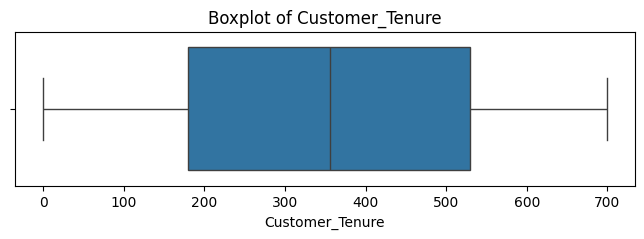

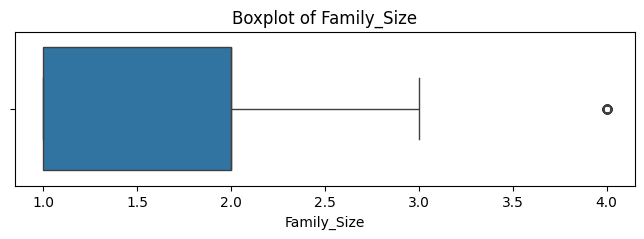

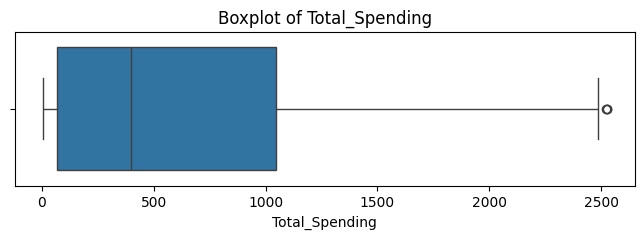

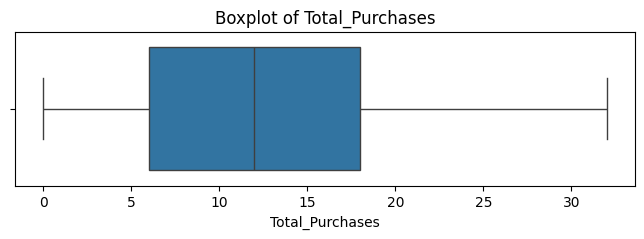

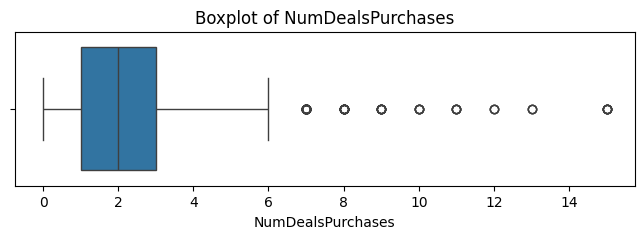

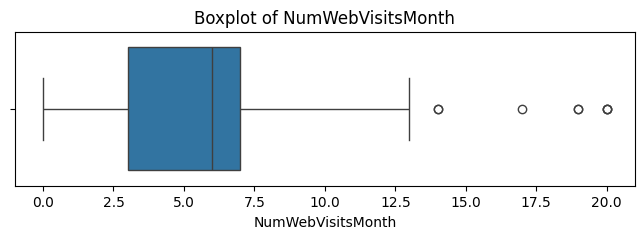

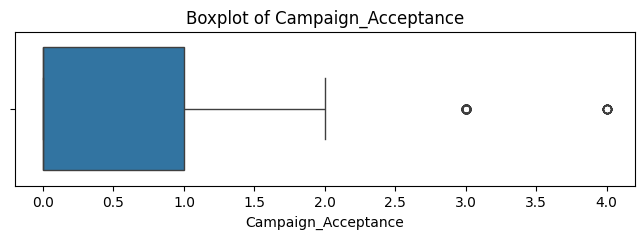

In [19]:
for col in df_cluster.columns:
    plt.figure(figsize=(8,2))
    sb.boxplot(x=df_cluster[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

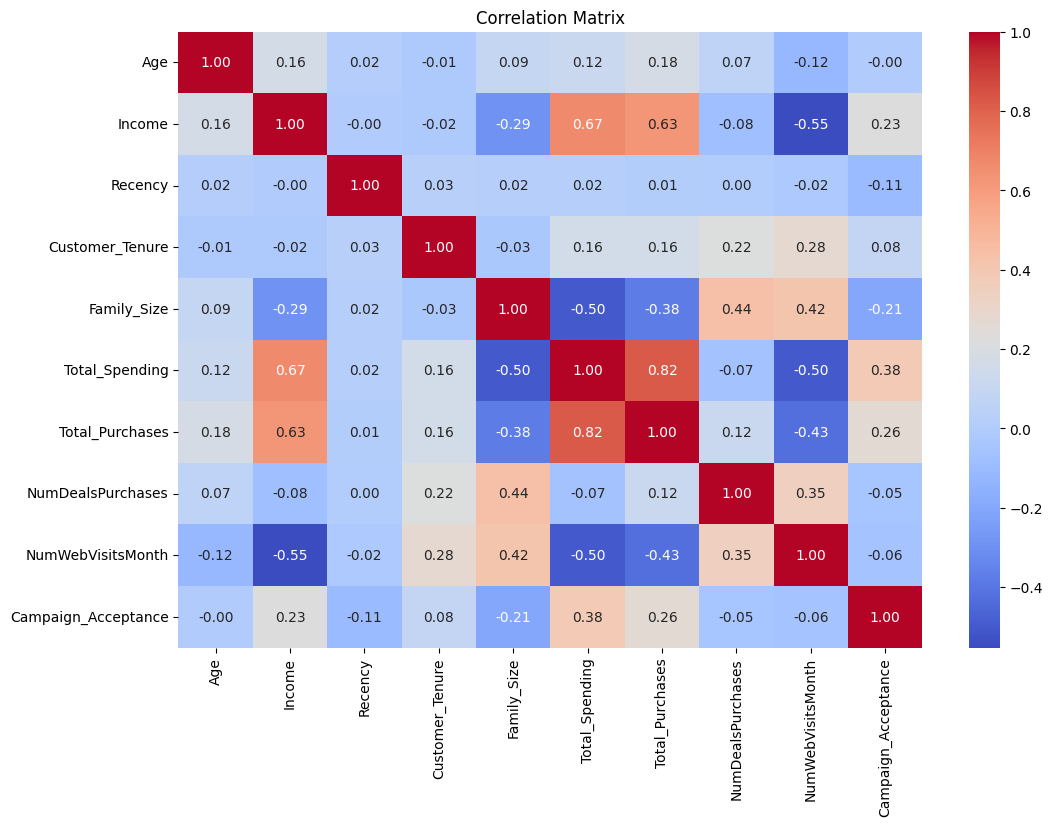

In [20]:
plt.figure(figsize=(12,8))

sb.heatmap(
    df_cluster.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

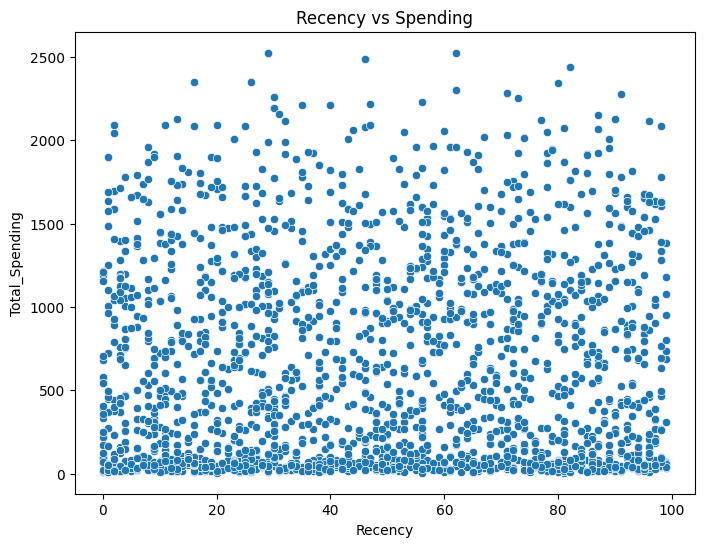

In [21]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    data=df_cluster,
    x='Recency',
    y='Total_Spending'
)

plt.title("Recency vs Spending")
plt.show()

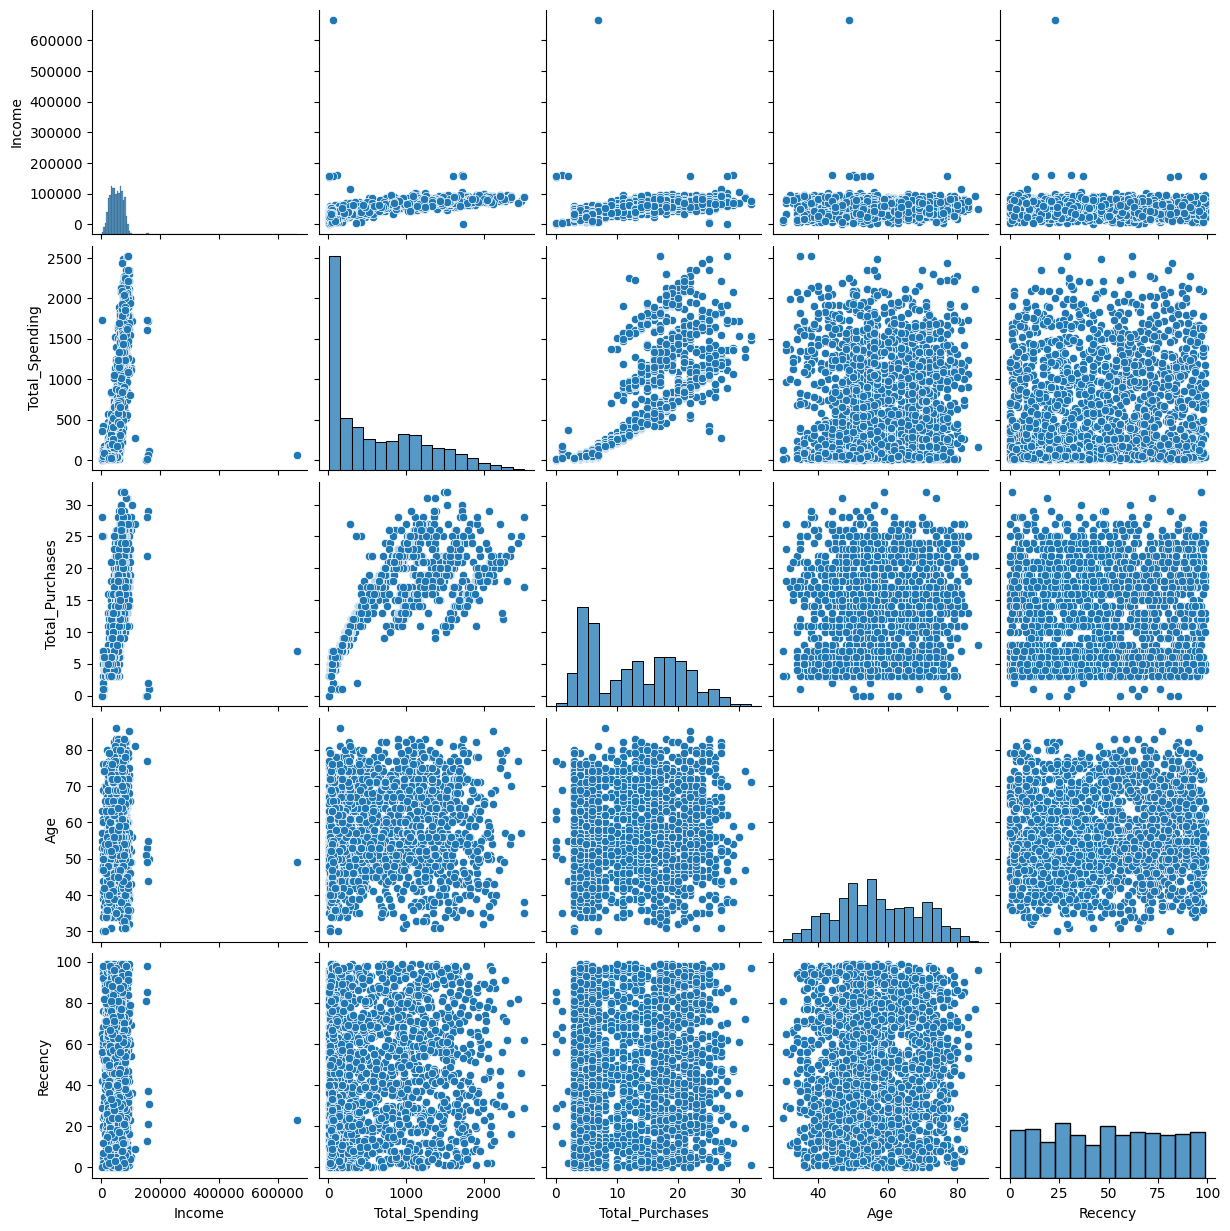

In [22]:
selected = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Age",
    "Recency"
]

sb.pairplot(
    df_cluster[selected]
)

plt.show()

In [23]:
df_cluster.dtypes

,0
Age,int64
Income,float64
Recency,int64
Customer_Tenure,int64
Family_Size,int64
Total_Spending,int64
Total_Purchases,int64
NumDealsPurchases,int64
NumWebVisitsMonth,int64
Campaign_Acceptance,int64


In [24]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
updated_df=ss.fit_transform(df_cluster)
print(updated_df.shape)

(2213, 10)


In [25]:
latest_df=pd.DataFrame(updated_df, columns=cluster_features)

latest_df.info()

latest_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2213 entries, 0 to 2212
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2213 non-null   float64
 1   Income               2213 non-null   float64
 2   Recency              2213 non-null   float64
 3   Customer_Tenure      2213 non-null   float64
 4   Family_Size          2213 non-null   float64
 5   Total_Spending       2213 non-null   float64
 6   Total_Purchases      2213 non-null   float64
 7   NumDealsPurchases    2213 non-null   float64
 8   NumWebVisitsMonth    2213 non-null   float64
 9   Campaign_Acceptance  2213 non-null   float64
dtypes: float64(10)
memory usage: 173.0 KB


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
0,1.018785,0.234435,0.310773,1.527968,-1.264914,1.676723,1.309929,0.350656,0.692198,0.841437
1,1.275248,-0.234084,-0.380424,-1.189356,1.404857,-0.962927,-1.188980,-0.169104,-0.132699,-0.506934
2,0.334882,0.769733,-0.795142,-0.206179,-1.264914,0.280531,1.032273,-0.688863,-0.545148,-0.506934
3,-1.289387,-1.016592,-0.795142,-1.060901,0.069971,-0.919763,-0.911323,-0.169104,0.279749,-0.506934
4,-1.032923,0.240593,1.554927,-0.952208,0.069971,-0.307165,0.199303,1.390175,-0.132699,-0.506934


In [26]:
print(latest_df.mean())
print(latest_df.std())

Age                   -4.093728e-17
Income                -5.056958e-17
Recency               -4.254266e-17
Customer_Tenure        1.091661e-16
Family_Size            0.000000e+00
Total_Spending        -4.013459e-17
Total_Purchases        9.391493e-17
NumDealsPurchases      0.000000e+00
NumWebVisitsMonth      5.137227e-17
Campaign_Acceptance    2.327806e-17
dtype: float64
Age                    1.000226
Income                 1.000226
Recency                1.000226
Customer_Tenure        1.000226
Family_Size            1.000226
Total_Spending         1.000226
Total_Purchases        1.000226
NumDealsPurchases      1.000226
NumWebVisitsMonth      1.000226
Campaign_Acceptance    1.000226
dtype: float64


In [27]:
b=latest_df.corr()
b

,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
Age,1.000000,0.163295,0.015971,-0.014273,0.092644,0.116150,0.175800,0.065866,-0.120355,-0.001552
Income,0.163295,1.000000,-0.003111,-0.018224,-0.292873,0.667516,0.626235,-0.082874,-0.552736,0.229025
Recency,0.015971,-0.003111,1.000000,0.025600,0.018030,0.020839,0.007773,0.002236,-0.019075,-0.108663
Customer_Tenure,-0.014273,-0.018224,0.025600,1.000000,-0.026125,0.158417,0.162940,0.217983,0.275690,0.084981
Family_Size,0.092644,-0.292873,0.018030,-0.026125,1.000000,-0.499866,-0.382827,0.436025,0.415559,-0.206091
Total_Spending,0.116150,0.667516,0.020839,0.158417,-0.499866,1.000000,0.823413,-0.065903,-0.498783,0.381546
Total_Purchases,0.175800,0.626235,0.007773,0.162940,-0.382827,0.823413,1.000000,0.116196,-0.427489,0.261073
NumDealsPurchases,0.065866,-0.082874,0.002236,0.217983,0.436025,-0.065903,0.116196,1.000000,0.345667,-0.049305
NumWebVisitsMonth,-0.120355,-0.552736,-0.019075,0.275690,0.415559,-0.498783,-0.427489,0.345667,1.000000,-0.055710
Campaign_Acceptance,-0.001552,0.229025,-0.108663,0.084981,-0.206091,0.381546,0.261073,-0.049305,-0.055710,1.000000


In [28]:
from sklearn.decomposition import PCA

In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(latest_df)

In [30]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,1.966381,1.881163
1,-1.553714,-0.769892
2,1.615427,-0.688675
3,-1.676980,-1.334649
4,-0.343517,0.117649


In [31]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.33019141 0.15879216]


In [32]:
total_variance = pca.explained_variance_ratio_.sum()

print("Total Variance Explained:", total_variance)

Total Variance Explained: 0.4889835769418882


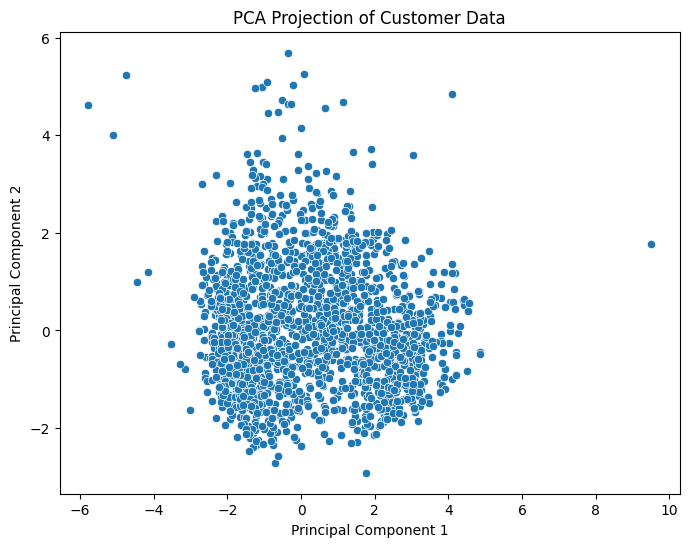

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"]
)

plt.title("PCA Projection of Customer Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

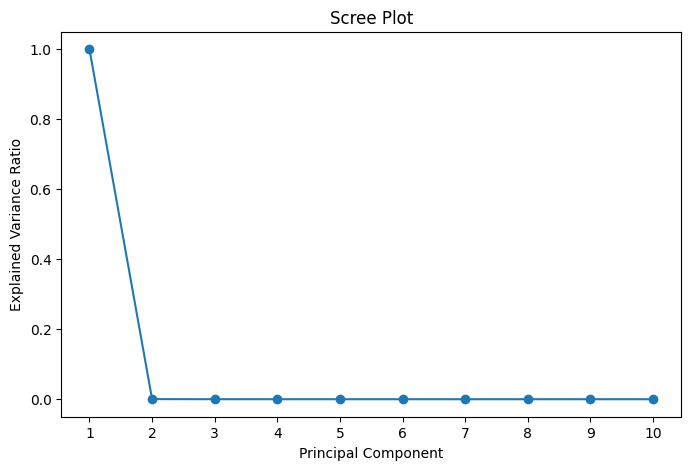

In [34]:
pca_full = PCA()
pca_full.fit(df_cluster)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

plt.show()

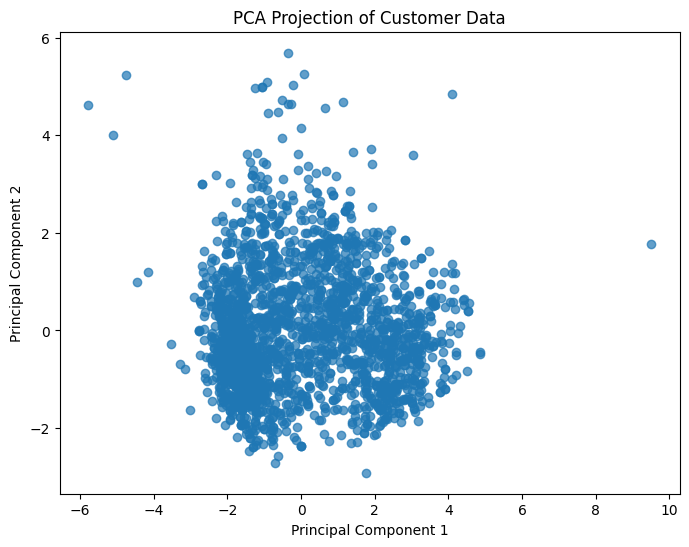

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Customer Data")

plt.show()

In [36]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_cluster.columns
)

print(loadings)

                          PC1       PC2
Age                  0.093236  0.170382
Income               0.439891  0.065877
Recency             -0.003883  0.006994
Customer_Tenure      0.015292  0.514752
Family_Size         -0.351637  0.271074
Total_Spending       0.497607  0.174275
Total_Purchases      0.455240  0.286266
NumDealsPurchases   -0.132898  0.618290
NumWebVisitsMonth   -0.389820  0.328248
Campaign_Acceptance  0.222325  0.160565


In [37]:
print(latest_df.describe())

                Age        Income       Recency  Customer_Tenure  Family_Size  \
count  2.213000e+03  2.213000e+03  2.213000e+03     2.213000e+03  2213.000000   
mean  -4.093728e-17 -5.056958e-17 -4.254266e-17     1.091661e-16     0.000000   
std    1.000226e+00  1.000226e+00  1.000226e+00     1.000226e+00     1.000226   
min   -2.315241e+00 -2.006386e+00 -1.693697e+00    -1.747643e+00    -1.264914   
25%   -6.909718e-01 -6.749549e-01 -8.642613e-01    -8.583364e-01    -1.264914   
50%   -9.255708e-02 -3.430598e-02 -2.654845e-04     1.120730e-02     0.069971   
75%    8.478090e-01  6.455518e-01  8.637304e-01     8.659293e-01     0.069971   
max    2.472078e+00  2.440836e+01  1.727726e+00     1.705829e+00     2.739742   

       Total_Spending  Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  \
count    2.213000e+03     2.213000e+03        2213.000000       2.213000e+03   
mean    -4.013459e-17     9.391493e-17           0.000000       5.137227e-17   
std      1.000226e+00     1.00

In [38]:
df_copy_income["Income"].sort_values(ascending=False).head(10)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0
1898,113734.0
646,105471.0


In [39]:
#remove the outlier from the income cause it will produce unrealistic result during PCA
df_copy_income = df_copy_income[df_copy_income["Income"] < 200000]
df_copy_income["Income"].describe()

,Income
count,2212.000000
mean,51958.810579
std,21527.278844
min,1730.000000
25%,35233.500000
50%,51371.000000
75%,68487.000000
max,162397.000000


In [40]:
#proper feature engineering and standardization
#features
cluster_features = [
    "Age",
    "Income",
    "Recency",
    "Customer_Tenure",
    "Family_Size",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Campaign_Acceptance"
]

X = df_copy_income[cluster_features]

#scale features
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=cluster_features
)

print(X_scaled.mean())
print(X_scaled.std(ddof=0))


#PCA rerun
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Explained Variance:")
print(pca.explained_variance_ratio_.sum())

Age                    6.183521e-17
Income                -1.252765e-16
Recency                4.015273e-18
Customer_Tenure       -4.497106e-17
Family_Size            1.349132e-16
Total_Spending         5.942604e-17
Total_Purchases       -1.252765e-16
NumDealsPurchases     -1.140338e-16
NumWebVisitsMonth      1.092154e-16
Campaign_Acceptance    3.212219e-17
dtype: float64
Age                    1.0
Income                 1.0
Recency                1.0
Customer_Tenure        1.0
Family_Size            1.0
Total_Spending         1.0
Total_Purchases        1.0
NumDealsPurchases      1.0
NumWebVisitsMonth      1.0
Campaign_Acceptance    1.0
dtype: float64
Explained Variance Ratio:
[0.34725253 0.15886943]
Total Explained Variance:
0.5061219612283059


In [41]:
# Machine learning  Algorithm

# 1.k-means clustering -> distance based algorithm
#features are standarized using StandardScaler above

from sklearn.cluster import KMeans


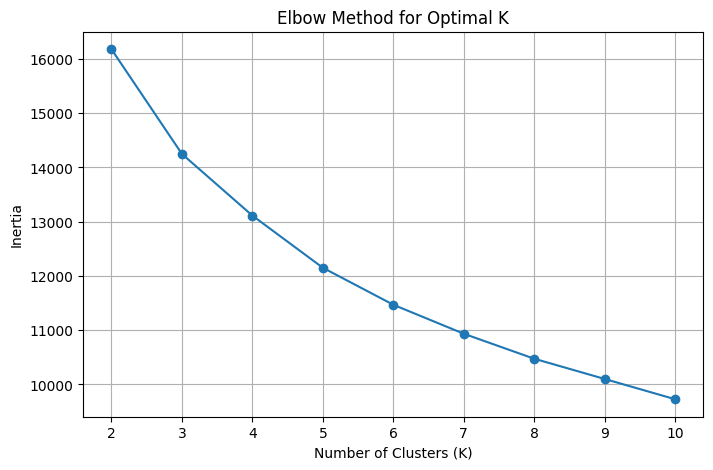

In [42]:
#Inertia measures how close customers are to the centroid of their assigned cluster.
#inertia decreases as K increases
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()


In [43]:
for k, value in zip(K, inertia):
    print(f"K = {k}, Inertia = {value:.2f}")


K = 2, Inertia = 16178.66
K = 3, Inertia = 14248.73
K = 4, Inertia = 13111.81
K = 5, Inertia = 12150.49
K = 6, Inertia = 11468.47
K = 7, Inertia = 10934.51
K = 8, Inertia = 10473.46
K = 9, Inertia = 10100.41
K = 10, Inertia = 9726.94


In [44]:
#Selection of specific numbers of cluster(k)
from sklearn.metrics import silhouette_score

silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)


for k, score in zip(K, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.2557
K = 3, Silhouette Score = 0.2101
K = 4, Silhouette Score = 0.2030
K = 5, Silhouette Score = 0.1553
K = 6, Silhouette Score = 0.1484
K = 7, Silhouette Score = 0.1424
K = 8, Silhouette Score = 0.1396
K = 9, Silhouette Score = 0.1392
K = 10, Silhouette Score = 0.1361


In [45]:
k_values = [2, 3, 4]

models = {}
clustered_data = {}

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    models[k] = model
    clustered_data[k] = labels

    print(f"K = {k}")
    print(pd.Series(labels).value_counts().sort_index())
    print("-" * 40)

K = 2
0    1296
1     916
Name: count, dtype: int64
----------------------------------------
K = 3
0    524
1    996
2    692
Name: count, dtype: int64
----------------------------------------
K = 4
0    604
1    976
2    414
3    218
Name: count, dtype: int64
----------------------------------------


In [46]:
#k=3 , each customer assigned with custom labels
#cluster 0 -> moderate income, moderate spending, discount oriented
#cluster 1 -> lowest income, lowest spending, budget customer
#cluster 2 -> high income, high spending, low discount oriented
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [47]:
df_clustered = X.copy()

df_clustered["Cluster"] = cluster_labels

In [48]:
cluster_profile = df_clustered.groupby("Cluster").mean().round(2)

print(cluster_profile)

           Age    Income  Recency  Customer_Tenure  Family_Size  \
Cluster                                                           
0        60.23  55158.79    49.30           466.10         2.33   
1        54.33  34463.38    48.86           309.25         2.20   
2        58.68  74716.99    49.03           332.61         1.30   

         Total_Spending  Total_Purchases  NumDealsPurchases  \
Cluster                                                       
0                702.15            16.55               4.69   
1                 99.86             5.96               1.84   
2               1265.74            19.06               1.24   

         NumWebVisitsMonth  Campaign_Acceptance  
Cluster                                          
0                     6.47                 0.37  
1                     6.35                 0.16  
2                     2.98                 0.69  


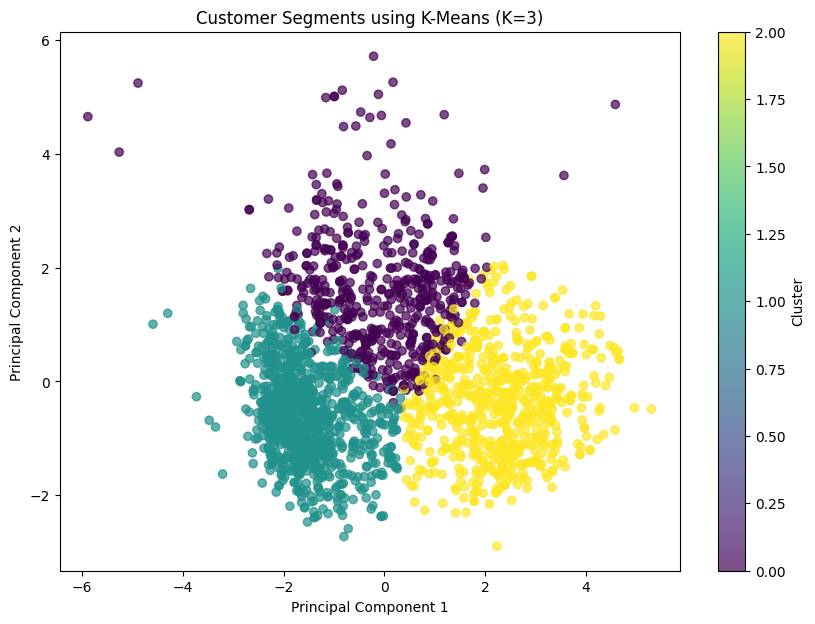

In [49]:
#visualize clustering using PCA
#Customer with same colour belongs to same Cluster
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels


import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using K-Means (K=3)")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [50]:
#centers learned by K-means and explains why each cluster was formed
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
)

centroids = centroids.round(2)

print(centroids)

#evaluation of K-means

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

kmeans_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)
print("Silhouette Score:", round(kmeans_silhouette,4))


dbi = davies_bouldin_score(
    X_scaled,
    cluster_labels
)
print("Davies-Bouldin Index:", round(dbi,4))


chi = calinski_harabasz_score(
    X_scaled,
    cluster_labels
)
print("Calinski-Harabasz Index:", round(chi,2))

    Age  Income  Recency  Customer_Tenure  Family_Size  Total_Spending  \
0  0.27    0.15     0.01             0.56         0.51            0.16   
1 -0.24   -0.81    -0.01            -0.22         0.33           -0.84   
2  0.14    1.06     0.00            -0.10        -0.87            1.09   

   Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  Campaign_Acceptance  
0             0.55               1.23               0.47                -0.01  
1            -0.92              -0.25               0.42                -0.29  
2             0.90              -0.57              -0.97                 0.43  
Silhouette Score: 0.2101
Davies-Bouldin Index: 1.7308
Calinski-Harabasz Index: 610.15


In [51]:
print(X_scaled.shape)
print(X_scaled.columns)

(2212, 10)
Index(['Age', 'Income', 'Recency', 'Customer_Tenure', 'Family_Size',
       'Total_Spending', 'Total_Purchases', 'NumDealsPurchases',
       'NumWebVisitsMonth', 'Campaign_Acceptance'],
      dtype='object')


DBSCAN


In [52]:
print(X_scaled.shape)

(2212, 10)


In [53]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Starting parameter
min_samples = 20

# Create nearest-neighbor model
neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

# Fit on the scaled dataset
neighbors_fit = neighbors.fit(X_scaled)

# Calculate distances to nearest neighbors
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take distance to the kth nearest neighbor and sort
k_distances = np.sort(
    distances[:, min_samples - 1]
)

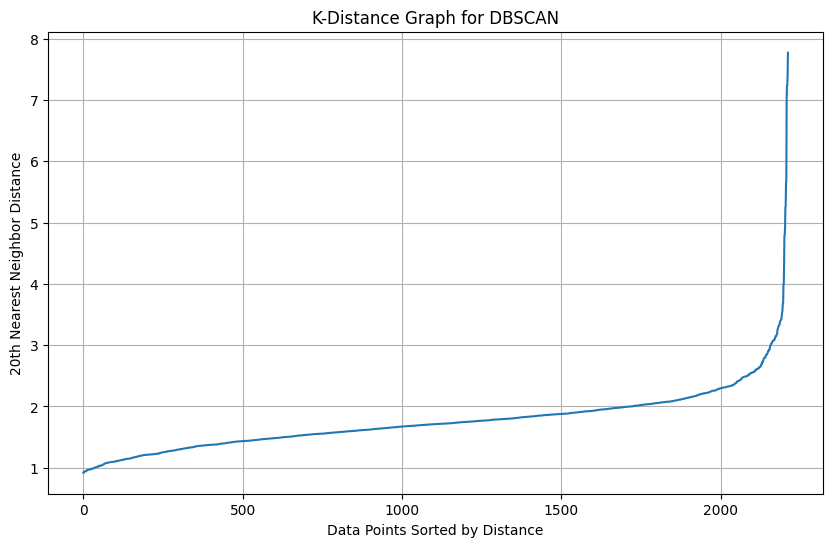

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("20th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.grid(True)

plt.show()

kata bata curve suru vako

In [55]:
print("Distance=",k_distances[2100])

Distance= 2.555339414319698


customer labeling gareko

In [56]:
from sklearn.cluster import DBSCAN

# Initialize DBSCAN
dbscan = DBSCAN(
    eps=2.56,
    min_samples=20
)

# Fit DBSCAN and assign cluster labels
dbscan_labels = dbscan.fit_predict(X_scaled)

In [57]:
print(dbscan_labels)

[0 0 0 ... 0 0 0]


In [58]:
from sklearn.cluster import DBSCAN
import pandas as pd

eps_values = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
min_samples_values = [5, 10, 15, 20]

results = []

for min_samples in min_samples_values:

    for eps in eps_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        # Number of clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Number of noise points
        n_noise = list(labels).count(-1)

        results.append({
            "min_samples": min_samples,
            "eps": eps,
            "Clusters": n_clusters,
            "Noise_Points": n_noise,
            "Noise_Percentage": round(
                (n_noise / len(labels)) * 100, 2
            )
        })

results_df = pd.DataFrame(results)

print(results_df)

    min_samples  eps  Clusters  Noise_Points  Noise_Percentage
0             5  1.0        28          1450             65.55
1             5  1.2        20           901             40.73
2             5  1.4        16           516             23.33
3             5  1.6         5           232             10.49
4             5  1.8         1           125              5.65
5             5  2.0         1            66              2.98
6            10  1.0         6          1822             82.37
7            10  1.2         8          1328             60.04
8            10  1.4         8           820             37.07
9            10  1.6         3           394             17.81
10           10  1.8         2           177              8.00
11           10  2.0         1            88              3.98
12           15  1.0         1          1970             89.06
13           15  1.2         5          1608             72.69
14           15  1.4         3          1049           

In [59]:
import numpy as np
import pandas as pd

# Number of clusters (excluding noise)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# Number of points in each cluster
print("\nCluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

Number of clusters: 1
Number of noise points: 29

Cluster counts:
-1      29
 0    2183
Name: count, dtype: int64


In [60]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

# Promising DBSCAN parameter combinations
candidates = [
    {"min_samples": 5, "eps": 1.6},
    {"min_samples": 10, "eps": 1.6},
    {"min_samples": 10, "eps": 1.8}
]

evaluation_results = []

for params in candidates:

    # Train DBSCAN
    dbscan = DBSCAN(
        eps=params["eps"],
        min_samples=params["min_samples"]
    )

    labels = dbscan.fit_predict(X_scaled)

    # Create mask to exclude noise points
    mask = labels != -1

    # Data and labels without noise
    X_non_noise = X_scaled[mask]
    labels_non_noise = labels[mask]

    # Count clusters excluding noise
    n_clusters = len(set(labels_non_noise))

    # Calculate metrics only if at least 2 clusters exist
    if n_clusters >= 2:

        silhouette = silhouette_score(
            X_non_noise,
            labels_non_noise
        )

        db_index = davies_bouldin_score(
            X_non_noise,
            labels_non_noise
        )

        ch_score = calinski_harabasz_score(
            X_non_noise,
            labels_non_noise
        )

    else:
        silhouette = None
        db_index = None
        ch_score = None

    evaluation_results.append({
        "min_samples": params["min_samples"],
        "eps": params["eps"],
        "Clusters": n_clusters,
        "Noise_Points": sum(labels == -1),
        "Noise_Percentage": round(
            sum(labels == -1) / len(labels) * 100, 2
        ),
        "Silhouette_Score": silhouette,
        "Davies_Bouldin_Index": db_index,
        "Calinski_Harabasz_Score": ch_score
    })

evaluation_df = pd.DataFrame(evaluation_results)

print(evaluation_df)

   min_samples  eps  Clusters  Noise_Points  Noise_Percentage  \
0            5  1.6         5           232             10.49   
1           10  1.6         3           394             17.81   
2           10  1.8         2           177              8.00   

   Silhouette_Score  Davies_Bouldin_Index  Calinski_Harabasz_Score  
0          0.140919              1.012609                20.112287  
1          0.001324              1.359609                23.880104  
2          0.311938              0.754895                19.097703  


In [61]:
from sklearn.cluster import DBSCAN

# Final DBSCAN model
dbscan_final = DBSCAN(
    eps=1.8,
    min_samples=10
)

# Generate cluster labels
dbscan_labels = dbscan_final.fit_predict(X_scaled)

In [62]:
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()

print("DBSCAN Cluster Distribution:")
print(cluster_counts)

# Number of clusters excluding noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = (dbscan_labels == -1).sum()

print("\nNumber of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)
print("Noise Percentage:", round((n_noise / len(dbscan_labels)) * 100, 2), "%")

DBSCAN Cluster Distribution:
-1     177
 0    2029
 1       6
Name: count, dtype: int64

Number of Clusters: 2
Number of Noise Points: 177
Noise Percentage: 8.0 %


In [63]:
df_dbscan = X.copy()

# Add DBSCAN cluster labels
df_dbscan["DBSCAN_Cluster"] = dbscan_labels

df_dbscan.head()


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance,DBSCAN_Cluster
0,69,58138.0,58,663,1,1617,22,3,7,1,0
1,72,46344.0,38,113,3,27,4,2,5,0,0
2,61,71613.0,26,312,1,776,20,1,4,0,0
3,42,26646.0,26,139,2,53,6,2,6,0,0
4,45,58293.0,94,161,2,422,14,5,5,0,0


In [64]:
# Customers assigned to actual clusters
df_dbscan_clusters = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] != -1
].copy()

# Customers identified as noise
df_dbscan_noise = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] == -1
].copy()

print("Clustered customers:", len(df_dbscan_clusters))
print("Noise customers:", len(df_dbscan_noise))

Clustered customers: 2035
Noise customers: 177


In [65]:
dbscan_profile = df_dbscan_clusters.groupby(
    "DBSCAN_Cluster"
).mean()

print(dbscan_profile.round(2))


                  Age    Income  Recency  Customer_Tenure  Family_Size  \
DBSCAN_Cluster                                                           
0               57.01  50602.09    49.26           349.12         1.96   
1               42.33  81947.83    45.50           129.50         1.00   

                Total_Spending  Total_Purchases  NumDealsPurchases  \
DBSCAN_Cluster                                                       
0                       562.21             12.1               2.22   
1                      1835.17             19.0               1.00   

                NumWebVisitsMonth  Campaign_Acceptance  
DBSCAN_Cluster                                          
0                            5.27                 0.26  
1                            2.00                 3.00  


In [66]:
noise_profile = df_dbscan_noise[
    cluster_features
].mean()

print("Noise Customer Profile:")
print(noise_profile.round(2))

Noise Customer Profile:
Age                       58.47
Income                 66494.75
Recency                   46.33
Customer_Tenure          413.97
Family_Size                1.88
Total_Spending          1082.19
Total_Purchases           17.66
NumDealsPurchases          3.59
NumWebVisitsMonth          6.08
Campaign_Acceptance        1.67
dtype: float64


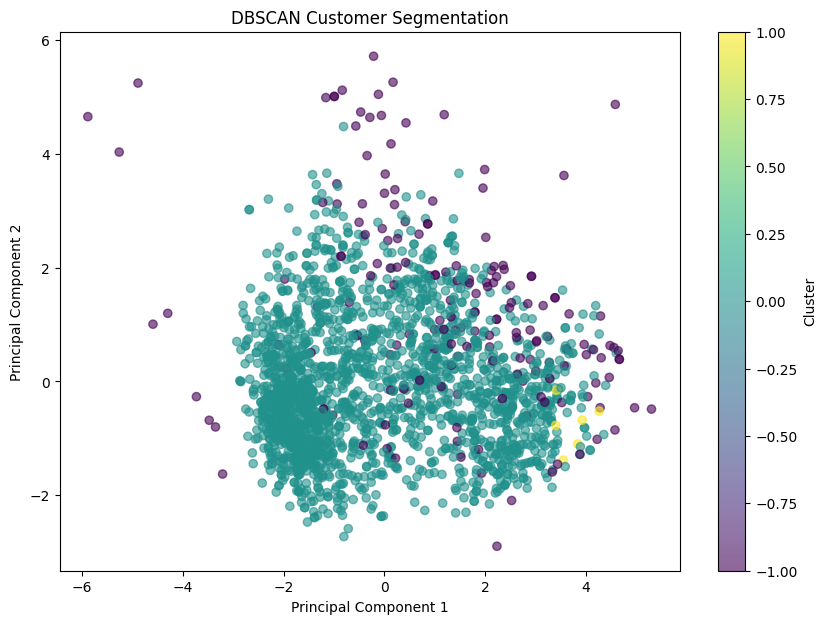

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce scaled data to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segmentation")

plt.colorbar(scatter, label="Cluster")

plt.show()


In [68]:
# Profile of actual DBSCAN clusters
cluster_profile = df_dbscan_clusters.groupby(
    "DBSCAN_Cluster"
)[cluster_features].mean()

# Noise profile as a DataFrame
noise_profile_df = pd.DataFrame(
    [df_dbscan_noise[cluster_features].mean()],
    index=["Noise"]
)

# Combine them
comparison_profile = pd.concat(
    [cluster_profile, noise_profile_df]
)

print(comparison_profile.round(2))


         Age    Income  Recency  Customer_Tenure  Family_Size  Total_Spending  \
0      57.01  50602.09    49.26           349.12         1.96          562.21   
1      42.33  81947.83    45.50           129.50         1.00         1835.17   
Noise  58.47  66494.75    46.33           413.97         1.88         1082.19   

       Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  \
0                12.10               2.22               5.27   
1                19.00               1.00               2.00   
Noise            17.66               3.59               6.08   

       Campaign_Acceptance  
0                     0.26  
1                     3.00  
Noise                 1.67  


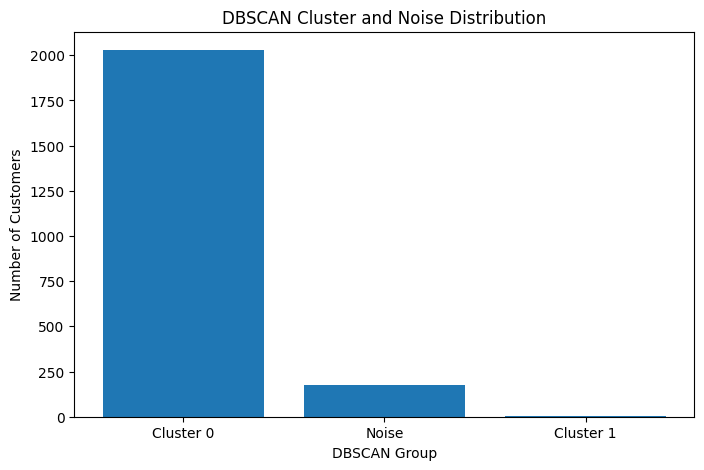

In [69]:
labels_for_plot = pd.Series(dbscan_labels).replace(
    {-1: "Noise", 0: "Cluster 0", 1: "Cluster 1"}
)

cluster_counts_plot = labels_for_plot.value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts_plot.index,
    cluster_counts_plot.values
)

plt.xlabel("DBSCAN Group")
plt.ylabel("Number of Customers")
plt.title("DBSCAN Cluster and Noise Distribution")

plt.show()

In [70]:
from sklearn.decomposition import PCA

# Create PCA model
pca_dbscan = PCA(n_components=2)

# Transform scaled data into 2 dimensions
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled)

# Check explained variance
print("Explained Variance Ratio:")
print(pca_dbscan.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca_dbscan.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.34725253 0.15886943]

Total Explained Variance:
0.5061219612283059


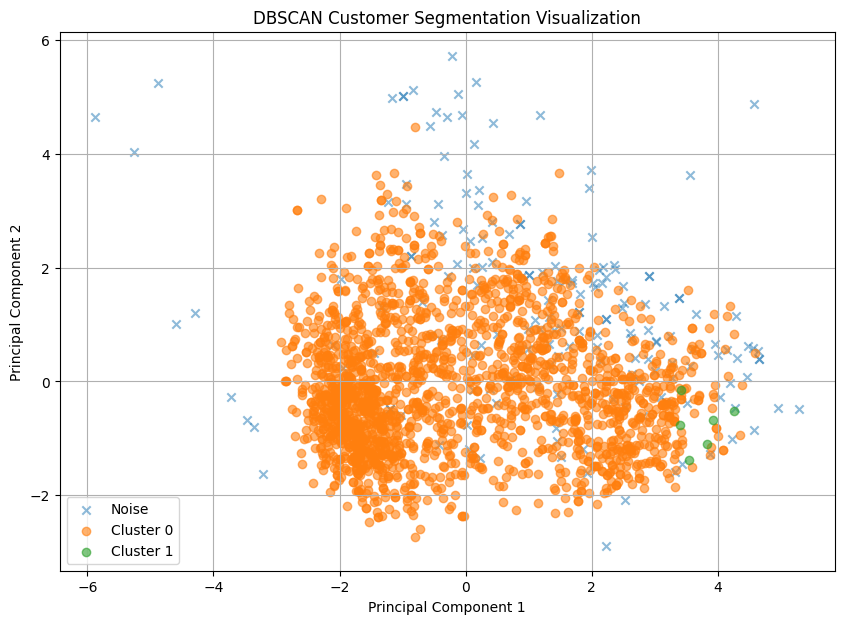

In [71]:
plt.figure(figsize=(10, 7))

# Plot noise points separately
noise_mask = dbscan_labels == -1

plt.scatter(
    X_pca_dbscan[noise_mask, 0],
    X_pca_dbscan[noise_mask, 1],
    label="Noise",
    alpha=0.5,
    marker="x"
)

# Plot actual clusters
for cluster in sorted(set(dbscan_labels)):

    if cluster != -1:

        cluster_mask = dbscan_labels == cluster

        plt.scatter(
            X_pca_dbscan[cluster_mask, 0],
            X_pca_dbscan[cluster_mask, 1],
            label=f"Cluster {cluster}",
            alpha=0.6
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segmentation Visualization")

plt.legend()

plt.grid(True)

plt.show()

In [72]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize each feature column for visualization
scaler_heatmap = StandardScaler()

profile_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(comparison_profile),
    index=comparison_profile.index,
    columns=comparison_profile.columns
)

print(profile_scaled.round(2))

        Age  Income  Recency  Customer_Tenure  Family_Size  Total_Spending  \
0      0.60   -1.23     1.38             0.42         0.80           -1.14   
1     -1.41    1.22    -0.95            -1.38        -1.41            1.29   
Noise  0.81    0.01    -0.44             0.96         0.61           -0.15   

       Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  \
0                -1.39              -0.05               0.46   
1                 0.92              -1.20              -1.39   
Noise             0.47               1.25               0.93   

       Campaign_Acceptance  
0                    -1.24  
1                     1.21  
Noise                 0.03  


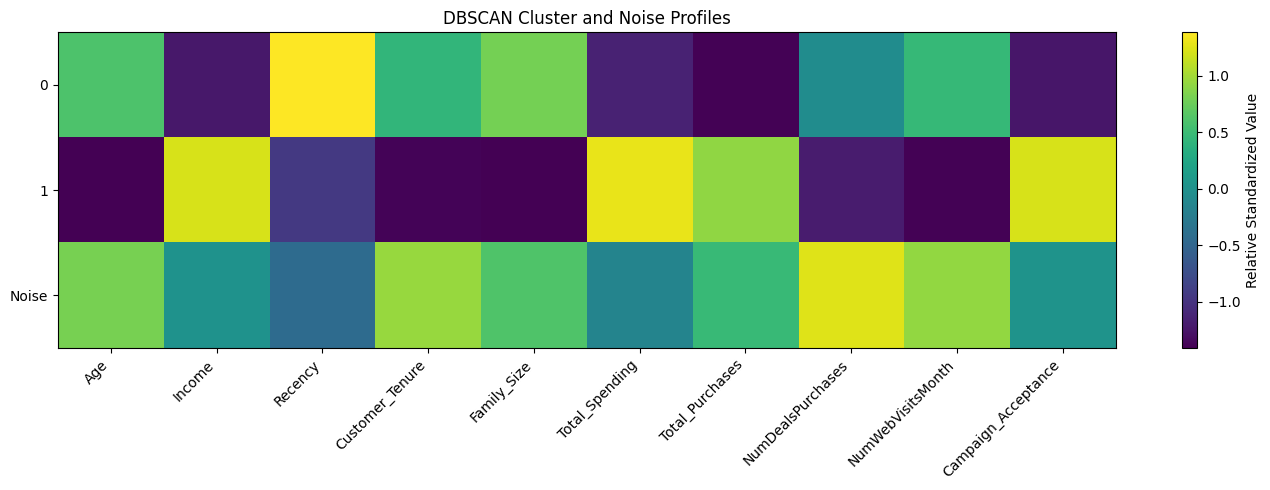

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.imshow(
    profile_scaled,
    aspect="auto"
)

plt.colorbar(label="Relative Standardized Value")

plt.xticks(
    range(len(cluster_features)),
    cluster_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_scaled.index)),
    profile_scaled.index
)

plt.title("DBSCAN Cluster and Noise Profiles")

plt.tight_layout()

plt.show()


In [74]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Exclude noise points
mask = dbscan_labels != -1

X_non_noise = X_scaled[mask]
labels_non_noise = dbscan_labels[mask]

# Calculate final metrics
silhouette_dbscan = silhouette_score(
    X_non_noise,
    labels_non_noise
)

davies_dbscan = davies_bouldin_score(
    X_non_noise,
    labels_non_noise
)

calinski_dbscan = calinski_harabasz_score(
    X_non_noise,
    labels_non_noise
)

print("Final DBSCAN Evaluation")
print("-" * 35)
print(f"Number of Clusters: {n_clusters}")
print(f"Noise Points: {n_noise}")
print(f"Noise Percentage: {(n_noise / len(dbscan_labels)) * 100:.2f}%")
print(f"Silhouette Score: {silhouette_dbscan:.4f}")
print(f"Davies-Bouldin Index: {davies_dbscan:.4f}")
print(f"Calinski-Harabasz Score: {calinski_dbscan:.2f}")

Final DBSCAN Evaluation
-----------------------------------
Number of Clusters: 2
Noise Points: 177
Noise Percentage: 8.00%
Silhouette Score: 0.3119
Davies-Bouldin Index: 0.7549
Calinski-Harabasz Score: 19.10


GMM

In [75]:
from sklearn.mixture import GaussianMixture

In [76]:
n_components_range = range(2, 11)

aic_scores = []
bic_scores = []

for k in n_components_range:

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_scaled)

    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

In [77]:
gmm_results = pd.DataFrame({
    "Number_of_Components": list(n_components_range),
    "AIC": aic_scores,
    "BIC": bic_scores
})

print(gmm_results)

   Number_of_Components           AIC           BIC
0                     2  45956.701014  46703.617474
1                     3  24310.884678  25434.110193
2                     4  22909.618297  24409.152868
3                     5  22748.421310  24624.264938
4                     6  14170.131426  16422.284109
5                     7  15195.705844  17824.167583
6                     8  11704.194681  14708.965476
7                     9  18352.711817  21733.791668
8                    10   8719.675835  12477.064742


In [78]:
gmm_final = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_final.fit(X_scaled)

gmm_labels = gmm_final.predict(X_scaled)

print("GMM model fitted successfully.")
print("Number of components:", gmm_final.n_components)


GMM model fitted successfully.
Number of components: 2


In [79]:
import pandas as pd

gmm_cluster_counts = pd.Series(gmm_labels).value_counts().sort_index()

print("GMM Cluster Sizes:")
print(gmm_cluster_counts)

GMM Cluster Sizes:
0    1225
1     987
Name: count, dtype: int64


In [80]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

gmm_silhouette = silhouette_score(
    X_scaled,
    gmm_labels
)

gmm_db = davies_bouldin_score(
    X_scaled,
    gmm_labels
)

gmm_ch = calinski_harabasz_score(
    X_scaled,
    gmm_labels
)

print("Number of Components:", gmm_final.n_components)
print("Silhouette Score:", round(gmm_silhouette, 4))
print("Davies-Bouldin Index:", round(gmm_db, 4))
print("Calinski-Harabasz Score:", round(gmm_ch, 2))

Number of Components: 2
Silhouette Score: 0.2109
Davies-Bouldin Index: 1.717
Calinski-Harabasz Score: 642.25


In [81]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

gmm_evaluation = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_scaled)

    labels = gmm.predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    gmm_evaluation.append({
        "Components": k,
        "AIC": gmm.aic(X_scaled),
        "BIC": gmm.bic(X_scaled),
        "Silhouette": silhouette,
        "Davies_Bouldin": db,
        "Calinski_Harabasz": ch
    })

gmm_evaluation_df = pd.DataFrame(gmm_evaluation)

print(gmm_evaluation_df.round(4))

   Components         AIC         BIC  Silhouette  Davies_Bouldin  \
0           2  45956.7010  46703.6175      0.2109          1.7170   
1           3  24310.8847  25434.1102      0.1580          2.5166   
2           4  22909.6183  24409.1529      0.0973          2.3172   
3           5  22748.4213  24624.2649      0.1199          2.4827   
4           6  14170.1314  16422.2841      0.0751          3.1307   
5           7  15195.7058  17824.1676      0.0373          3.0325   
6           8  11704.1947  14708.9655      0.0901          3.2784   
7           9  18352.7118  21733.7917      0.0859          2.4678   
8          10   8719.6758  12477.0647      0.0423          2.8669   

   Calinski_Harabasz  
0           642.2522  
1           378.6164  
2           303.2710  
3           280.6127  
4           171.7363  
5           131.6927  
6           155.2605  
7           172.9668  
8           138.4293  


In [82]:
gmm_final = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_final.fit(X_scaled)

gmm_labels = gmm_final.predict(X_scaled)

print("Final GMM model fitted successfully.")
print("Number of Components:", gmm_final.n_components)


gmm_cluster_counts = (
    pd.Series(gmm_labels)
    .value_counts()
    .sort_index()
)

print("Final GMM Cluster Sizes:")
print(gmm_cluster_counts)

Final GMM model fitted successfully.
Number of Components: 2
Final GMM Cluster Sizes:
0    1225
1     987
Name: count, dtype: int64


In [83]:
df_gmm = X.copy()

# Add GMM cluster labels
df_gmm["GMM_Cluster"] = gmm_labels

print(df_gmm.head())


gmm_profile = (
    df_gmm
    .groupby("GMM_Cluster")[cluster_features]
    .mean()
)
print("GMM Cluster Profile:")
print(gmm_profile.round(2))

   Age   Income  Recency  Customer_Tenure  Family_Size  Total_Spending  \
0   69  58138.0       58              663            1            1617   
1   72  46344.0       38              113            3              27   
2   61  71613.0       26              312            1             776   
3   42  26646.0       26              139            2              53   
4   45  58293.0       94              161            2             422   

   Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  Campaign_Acceptance  \
0               22                  3                  7                    1   
1                4                  2                  5                    0   
2               20                  1                  4                    0   
3                6                  2                  6                    0   
4               14                  5                  5                    0   

   GMM_Cluster  
0            0  
1            1  
2            0  


In [84]:
gmm_profile = (
    df_gmm
    .groupby("GMM_Cluster")[cluster_features]
    .mean()
)

print("GMM Cluster Profile:")
print(gmm_profile.round(2))

GMM Cluster Profile:
               Age    Income  Recency  Customer_Tenure  Family_Size  \
GMM_Cluster                                                           
0            58.88  65889.82    49.03           380.79         1.70   
1            54.86  34668.55    49.00           320.11         2.25   

             Total_Spending  Total_Purchases  NumDealsPurchases  \
GMM_Cluster                                                       
0                   1023.73            18.03               2.60   
1                     90.38             5.79               1.98   

             NumWebVisitsMonth  Campaign_Acceptance  
GMM_Cluster                                          
0                         4.49                 0.55  
1                         6.36                 0.17  


In [85]:
gmm_cluster_counts = (
    df_gmm["GMM_Cluster"]
    .value_counts()
    .sort_index()
)

print("GMM Cluster Sizes:")
print(gmm_cluster_counts)

GMM Cluster Sizes:
GMM_Cluster
0    1225
1     987
Name: count, dtype: int64


In [86]:
# Calculate membership probabilities
gmm_probabilities = gmm_final.predict_proba(X_scaled)

# Add probabilities to the GMM dataset
df_gmm["Probability_Cluster_0"] = gmm_probabilities[:, 0]
df_gmm["Probability_Cluster_1"] = gmm_probabilities[:, 1]

print(df_gmm.head())

#probability distribution
print("Average membership probability:")
print(
    df_gmm[
        ["Probability_Cluster_0", "Probability_Cluster_1"]
    ].mean().round(4)
)

#Confidence
df_gmm["GMM_Confidence"] = gmm_probabilities.max(axis=1)

print("GMM Confidence:")
print(df_gmm["GMM_Confidence"].describe().round(4))

   Age   Income  Recency  Customer_Tenure  Family_Size  Total_Spending  \
0   69  58138.0       58              663            1            1617   
1   72  46344.0       38              113            3              27   
2   61  71613.0       26              312            1             776   
3   42  26646.0       26              139            2              53   
4   45  58293.0       94              161            2             422   

   Total_Purchases  NumDealsPurchases  NumWebVisitsMonth  Campaign_Acceptance  \
0               22                  3                  7                    1   
1                4                  2                  5                    0   
2               20                  1                  4                    0   
3                6                  2                  6                    0   
4               14                  5                  5                    0   

   GMM_Cluster  Probability_Cluster_0  Probability_Cluster_1  
0    

In [87]:
gmm_final_silhouette = silhouette_score(
    X_scaled,
    gmm_labels
)

gmm_final_db = davies_bouldin_score(
    X_scaled,
    gmm_labels
)

gmm_final_ch = calinski_harabasz_score(
    X_scaled,
    gmm_labels
)

print("Final GMM Evaluation")
print("-----------------------------------")
print("Components:", gmm_final.n_components)
print("Silhouette:", round(gmm_final_silhouette, 4))
print("Davies-Bouldin:", round(gmm_final_db, 4))
print("Calinski-Harabasz:", round(gmm_final_ch, 2))

Final GMM Evaluation
-----------------------------------
Components: 2
Silhouette: 0.2109
Davies-Bouldin: 1.717
Calinski-Harabasz: 642.25


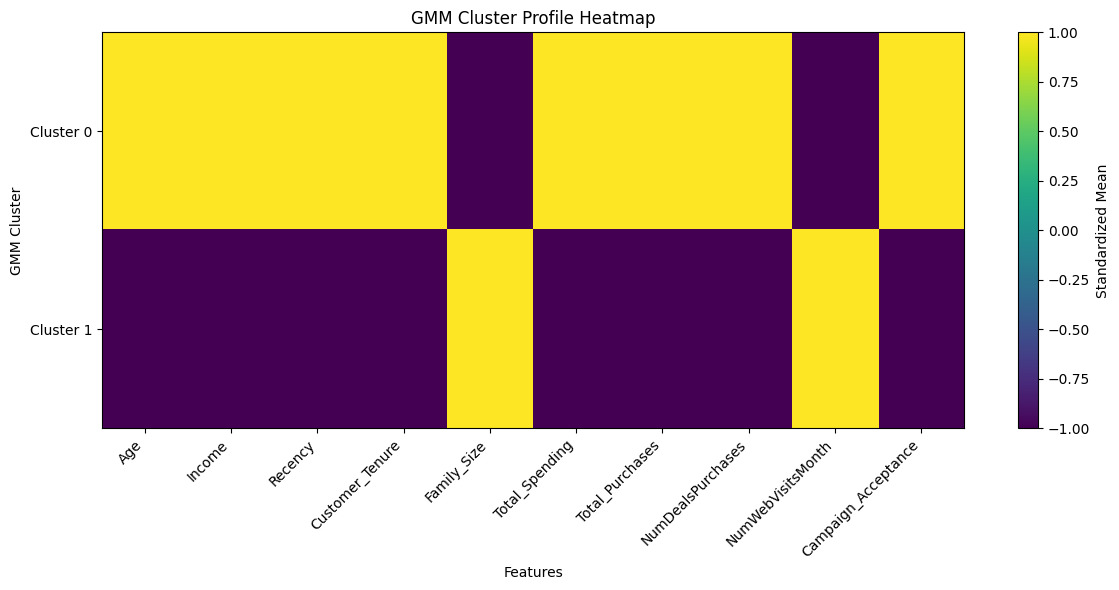

In [88]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(gmm_profile),
    index=gmm_profile.index,
    columns=gmm_profile.columns
)

plt.figure(figsize=(12, 6))

plt.imshow(profile_scaled, aspect="auto")

plt.xticks(
    range(len(profile_scaled.columns)),
    profile_scaled.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_scaled.index)),
    ["Cluster 0", "Cluster 1"]
)

plt.xlabel("Features")
plt.ylabel("GMM Cluster")
plt.title("GMM Cluster Profile Heatmap")

plt.colorbar(label="Standardized Mean")

plt.tight_layout()
plt.show()


In [89]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# K-Means
kmeans_metrics = [
    silhouette_score(X_scaled, cluster_labels),
    davies_bouldin_score(X_scaled, cluster_labels),
    calinski_harabasz_score(X_scaled, cluster_labels)
]

# DBSCAN - exclude noise points
mask = dbscan_labels != -1

dbscan_metrics = [
    silhouette_score(X_scaled[mask], dbscan_labels[mask]),
    davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]),
    calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
]

# GMM
gmm_metrics = [
    silhouette_score(X_scaled, gmm_labels),
    davies_bouldin_score(X_scaled, gmm_labels),
    calinski_harabasz_score(X_scaled, gmm_labels)
]

# Final comparison
comparison = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "K-Means": kmeans_metrics,
    "DBSCAN": dbscan_metrics,
    "GMM": gmm_metrics
})

comparison.round(4)

,Metric,K-Means,DBSCAN,GMM
0,Silhouette Score,0.2101,0.3119,0.2109
1,Davies-Bouldin Index,1.7308,0.7549,1.7170
2,Calinski-Harabasz Score,610.1472,19.0977,642.2522


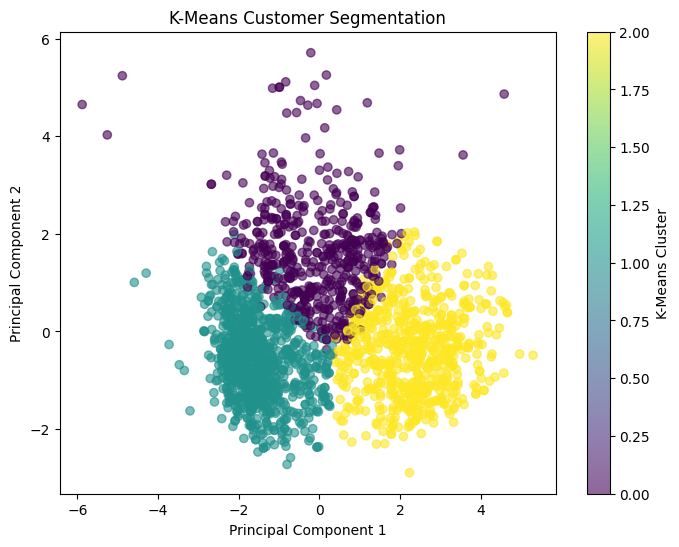

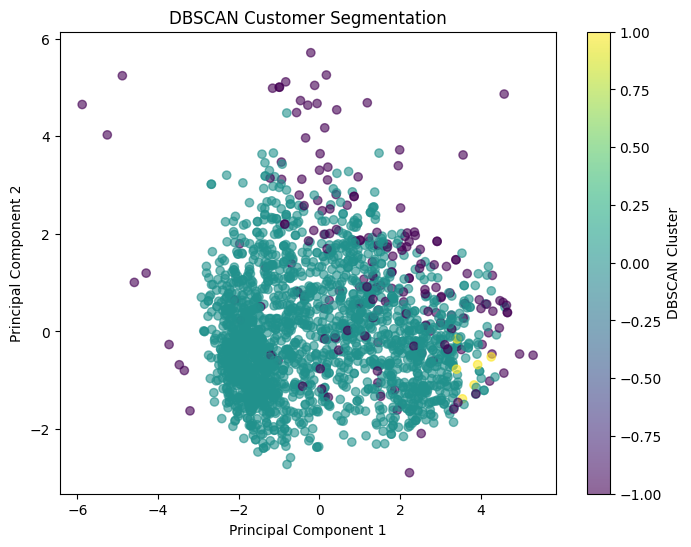

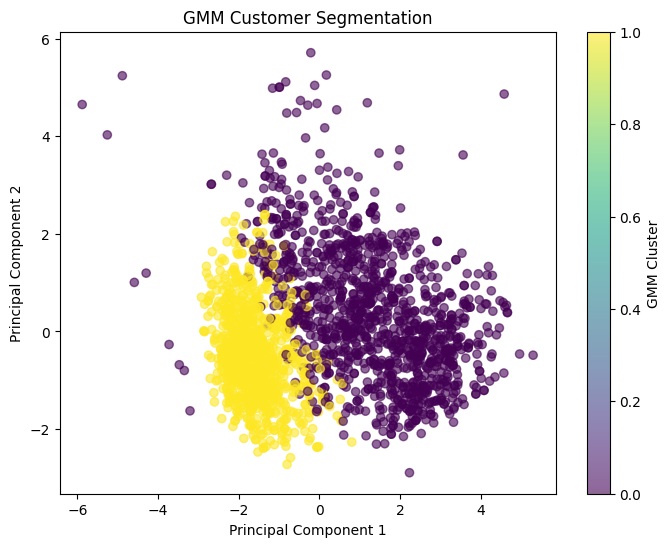

In [90]:
import matplotlib.pyplot as plt

# Transform the scaled data into the same 2D PCA space
X_pca = pca.transform(X_scaled)

# -----------------------------
# 1. K-Means
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Segmentation")
plt.colorbar(label="K-Means Cluster")
plt.show()


# -----------------------------
# 2. DBSCAN
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segmentation")
plt.colorbar(label="DBSCAN Cluster")
plt.show()


# -----------------------------
# 3. GMM
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Customer Segmentation")
plt.colorbar(label="GMM Cluster")
plt.show()

In [91]:
# K-Means profile
kmeans_profile = (
    X.assign(Cluster=cluster_labels)
    .groupby("Cluster")
    .mean()
    .round(2)
)

print("K-Means Cluster Profile")
display(kmeans_profile)


# DBSCAN profile
dbscan_profile = (
    X.assign(Cluster=dbscan_labels)
    .groupby("Cluster")
    .mean()
    .round(2)
)

print("DBSCAN Cluster Profile")
display(dbscan_profile)


# GMM profile
gmm_profile = (
    X.assign(Cluster=gmm_labels)
    .groupby("Cluster")
    .mean()
    .round(2)
)

print("GMM Cluster Profile")
display(gmm_profile)

K-Means Cluster Profile


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
Cluster,,,,,,,,,,
0,60.23,55158.79,49.30,466.10,2.33,702.15,16.55,4.69,6.47,0.37
1,54.33,34463.38,48.86,309.25,2.20,99.86,5.96,1.84,6.35,0.16
2,58.68,74716.99,49.03,332.61,1.30,1265.74,19.06,1.24,2.98,0.69


DBSCAN Cluster Profile


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
Cluster,,,,,,,,,,
-1,58.47,66494.75,46.33,413.97,1.88,1082.19,17.66,3.59,6.08,1.67
0,57.01,50602.09,49.26,349.12,1.96,562.21,12.10,2.22,5.27,0.26
1,42.33,81947.83,45.50,129.50,1.00,1835.17,19.00,1.00,2.00,3.00


GMM Cluster Profile


,Age,Income,Recency,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Campaign_Acceptance
Cluster,,,,,,,,,,
0,58.88,65889.82,49.03,380.79,1.70,1023.73,18.03,2.60,4.49,0.55
1,54.86,34668.55,49.00,320.11,2.25,90.38,5.79,1.98,6.36,0.17


In [92]:
print("K-Means")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nDBSCAN")
print(pd.Series(dbscan_labels).value_counts().sort_index())

print("\nGMM")
print(pd.Series(gmm_labels).value_counts().sort_index())

K-Means
0    524
1    996
2    692
Name: count, dtype: int64

DBSCAN
-1     177
 0    2029
 1       6
Name: count, dtype: int64

GMM
0    1225
1     987
Name: count, dtype: int64


In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

seeds = [1, 10, 42, 100, 500]

kmeans_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    kmeans_results.append(labels)

# Compare every result with the first result
for i in range(1, len(kmeans_results)):
    score = adjusted_rand_score(
        kmeans_results[0],
        kmeans_results[i]
    )

    print(
        f"Seed {seeds[0]} vs Seed {seeds[i]}: "
        f"ARI = {score:.4f}"
    )

Seed 1 vs Seed 10: ARI = 0.9771
Seed 1 vs Seed 42: ARI = 0.9763
Seed 1 vs Seed 100: ARI = 0.9663
Seed 1 vs Seed 500: ARI = 0.9547


In [94]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

gmm_results = []

for seed in seeds:
    model = GaussianMixture(
        n_components=2,
        random_state=seed
    )

    labels = model.fit_predict(X_scaled)

    gmm_results.append(labels)

# Compare every result with the first result
for i in range(1, len(gmm_results)):
    score = adjusted_rand_score(
        gmm_results[0],
        gmm_results[i]
    )

    print(
        f"Seed {seeds[0]} vs Seed {seeds[i]}: "
        f"ARI = {score:.4f}"
    )

Seed 1 vs Seed 10: ARI = 1.0000
Seed 1 vs Seed 42: ARI = 1.0000
Seed 1 vs Seed 100: ARI = 1.0000
Seed 1 vs Seed 500: ARI = 1.0000


**DASHBOARD CODE: **



In [95]:
import pickle

# Save all your data
data = {
    'X_scaled': X_scaled,
    'kmeans_labels': cluster_labels,
    'dbscan_labels': dbscan_labels,
    'gmm_labels': gmm_labels
}

with open('segmentation_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Data saved successfully!")

✅ Data saved successfully!


In [96]:
!pip install streamlit plotly pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 89.3 MB/s eta 0:00:00


In [97]:
!grep -n "to_numpy" colab_streamlit_dashboard_2.py

300:        X_scaled = X_scaled.to_numpy()


In [106]:
from pyngrok import ngrok

ngrok.set_auth_token("enter your token")

print("✅ ngrok authenticated")

✅ ngrok authenticated


In [111]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [112]:
import subprocess
import time
import os

# Stop any old Streamlit process
os.system("pkill -f streamlit")
time.sleep(2)

# Start your dashboard
streamlit_process = subprocess.Popen([
    "streamlit",
    "run",
    "colab_streamlit_dashboard_2.py",
    "--server.headless=true",
    "--server.port=8502"
])

print("⏳ Starting dashboard...")
time.sleep(8)

if streamlit_process.poll() is None:
    print("✅ Streamlit dashboard is running!")
else:
    print("❌ Streamlit failed to start.")

⏳ Starting dashboard...
✅ Streamlit dashboard is running!


In [113]:
import subprocess
import re
import time

# Start Cloudflare tunnel
cloudflare_process = subprocess.Popen(
    [
        "./cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8502",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("⏳ Creating public dashboard link...")

public_url = None

for line in cloudflare_process.stdout:
    match = re.search(
        r'https://[a-zA-Z0-9.-]+\.trycloudflare\.com',
        line
    )

    if match:
        public_url = match.group(0)
        break

if public_url:
    print("\n🎉 DASHBOARD READY!")
    print("\nOPEN THIS LINK:")
    print(public_url)
else:
    print("❌ Could not create Cloudflare link.")

⏳ Creating public dashboard link...

🎉 DASHBOARD READY!

OPEN THIS LINK:
https://several-counter-excessive-ada.trycloudflare.com


In [108]:
from pyngrok import ngrok
import subprocess
import time
import os

# Stop any old Streamlit processes
os.system("pkill -f streamlit")

# Close old ngrok tunnels
ngrok.kill()

time.sleep(2)

# Start the corrected dashboard
process = subprocess.Popen([
    "streamlit",
    "run",
    "colab_streamlit_dashboard_2.py",
    "--server.headless=true",
    "--server.port=8502"
])

print("⏳ Starting Streamlit...")
time.sleep(8)

# Check if Streamlit started
if process.poll() is None:
    print("✅ Streamlit is running")

    try:
        public_url = ngrok.connect(
            addr=8502,
            proto="http"
        )

        print("\n🎉 DASHBOARD READY")
        print("\nOPEN THIS LINK:\n")
        print(public_url.public_url)

    except Exception as e:
        print("❌ ngrok failed:")
        print(e)

else:
    print("❌ Streamlit failed to start")

⏳ Starting Streamlit...
✅ Streamlit is running
❌ ngrok failed:
ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://pacify-pencil-obscurity.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}



In [102]:
from pyngrok import ngrok
import subprocess
import time
import os

# Stop any old Streamlit processes
os.system("pkill -f streamlit")

# Stop any old ngrok tunnels
ngrok.kill()

time.sleep(2)

# Start the NEW dashboard on a NEW port
process = subprocess.Popen([
    'streamlit',
    'run',
    'colab_streamlit_dashboard_2.py',
    '--server.headless', 'true',
    '--server.port', '8502'
])

time.sleep(5)

# Create ngrok tunnel to the same NEW port
public_url = ngrok.connect(8502)

print("\n✅ OPEN THIS NEW LINK:\n")
print(public_url)



from pyngrok import ngrok

# Set your free ngrok token (get from https://dashboard.ngrok.com/auth)
ngrok.set_auth_token("enter your token")

import subprocess
import time

# Start Streamlit
subprocess.Popen(['streamlit', 'run', 'colab_streamlit_dashboard_2.py',
                  '--server.headless', 'true',
                  '--server.port', '8501'])

time.sleep(3)

# Get public URL
public_url = ngrok.connect(8501)
print(f"\n OPEN IN CHROME:\n{public_url}\n")

ERROR:pyngrok.process.ngrok:t=2026-09-06T19:50:40+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NEW_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NEW_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.